In [1]:
import torch 
from torch.utils.data import Dataset 

import numpy as np

import sys, os
from gmm import GMM
from os.path import join, expanduser 
sys.path.append(join(expanduser("~"), "Documents/ML-Control-Rob/levelsetpy"))


import matplotlib 
%matplotlib inline 

import matplotlib.pyplot as plt

## Problem Statement and Numerical Setting

Let $\Omega = [0,L]\subset \mathbb{R}$ be the spatial domain indicated by the variable $\omega$, and let $(0,T]\subset\mathbb{R}$ be the time domain with variable $t$.
We consider the three-dimensional HJ equation with homogeneous Dirichlet boundary conditions,
$$
\begin{align*}
    &\partial \bm{v}_t(t; \bm{x}) + \min\{0, \bm{H}\left(x, \partial \bm{v}_{\bm{x}}(t; \bm{x})\right)\} = 0, \qquad &\bm{v}(0; \bm{x}) = \bm{g}(0; \bm{x}) \nonumber \\
%\bm{v}(0; \bm{x}) &= \bm{g}(0; \bm{x}) \\
%
&\approx \partial \bm{v}^\delta_t(t; \bm{x}) + \min\{0, 
\bm{H}^\delta\left(t; x, \partial \bm{v}^\delta_{\bm{x}}\right)\} = 0, \qquad &\bm{v}^\delta(0; \bm{x}) = \bm{g}(0; \bm{x}) \nonumber \\
%
&:= \partial \bm{v}^\delta_t(t; \bm{x}) + \min\bigg\{0, 
\max_{\bm{u} \in \mathcal{U}} \min_{\bm{w} \in \mathcal{W}} \, \bigg\langle f(t; \bm{x}, \bm{u}, \bm{w}), \frac{1}{t}(\bm{x} - \text{prox}_{t\bm{g}}(\bm{x})) \bigg\rangle
\bigg\} = 0 \qquad &\bm{v}^\delta(0; \bm{x}) = \bm{g}(0; \bm{x}).
\end{align*}
$$

This is a model for a one-dimensional rod that conducts heat: the temperature at the ends of the rod are fixed at $0$ and heat is allowed to flow out of the rod through the ends.

In [ ]:
class RocketDynamics():
    def __init__(self, u_bound=1, w_bound=1, T=1, L=64, a=32, g=32, resolution=100, rank='cpu'):    
        """
            Rockets Dynamics in relative coordinates.
            The equations of motion are adopted from Dreyfus' construction.

            In relative coordinates between the two rockets, we have
                    &\dot{x} = a(cos(u_p)+ cos(u_e)),\\
                    &\dot{z} = a(sin(u_p)+sin(u_e))-2g,\\
                    &\dot{θ} = u_p - u_e

            Parameters
            ==========
               [x] u_bound: absolute value of the linear speed of the vehicle.
               [x] w_bound: absolute value of the angular speed of the vehicle.
               [x] T:  Temporal domain length (final simulation time).
               [x] L: Spatial domain resolution.
               [x] a: acceleration in ft/sec^2.
               [x] g: gravitational acceleration in ft/sec^2.
               [x] resolution: spattial domain resolution.
               [x] rank: on what GPU(s) to try this algo.
        
        """    
        self.T = T                      # Temporal domain length (final simulation time).
        k = T*10**3 + 1                 # Temporal grid size.
        eps = sys.float_info.epsilon
        self.small = 100*eps
        self.device = rank

        self.t_range = torch.linspace(0, T, k)
        self.t_now = self.t_range[0]
        self.t_steps = self.t_range[1] -  self.t_range[0]

        # inputs 
        self.u = u_bound
        self.w = w_bound
        self.a = a; self.g = g 

        # generate the spatial domain whereupon v(t;x) is domiciled
        self.state_space = self.get_state_space(L, resolution)
        self.state_domain = self.get_state_domain()
        self.initial_conditions = self.get_initial_conditions(L)
        self.values = self.get_values(self.state_domain)

        self.state_dim = self.state_space[0].shape[0]

        self.gmm = GMM(device=rank)
        self.gmm_denom = GMM(device=rank)

    def get_state_space(self, L, resolution):        
        # State components, $(x, z, \θ)$
        state_x = torch.linspace(-L, +L, resolution).to(self.device)  # x spatial grid.
        state_z = torch.linspace(-L, +L, resolution).to(self.device)  # z spatial grid.
        state_orient = torch.linspace(-torch.pi/2, +torch.pi/2, resolution).to(self.device)  # x spatial grid.
        # X_all, Z_all, θ_all = torch.meshgrid(*(state_x, state_z, state_orient), indexing='ij') 
        
        return (state_x, state_z, state_orient)
    
    def get_state_domain(self):
        # interior of the spatial grids ==> Domain of the problem 
        X, Z, θ = self.state_space

        X_int = X[1:-1]
        Z_int = Z[1:-1]
        θ_int = θ[1:-1]

        return X_int, Z_int, θ_int

    def get_initial_conditions(self, L):
        
        X_int, Z_int, θ_int = self.state_domain

        # initial conditions
        X_0 = L/2.0 * torch.ones_like(X_int, device=self.device) 
        Z_0 = L/2.0 * torch.ones_like(Z_int, device=self.device) 
        θ_0 = -torch.pi/4.0 * torch.ones_like(Z_int, device=self.device) 

        return X_0, Z_0, θ_0
    
    def get_values(self, states):
        """
           [x] The value is the l\_2 distance to the boundary of the target region in the x-z plane.

           Parameters
           ==========
           states: x, z, θ over the whole statge space 
           a, g, u: see opening doc in class def.
        """
        if isinstance(states, list) or isinstance(states, tuple):
            X, _, θ = states
        else:
            print(states.shape)
            X, _, θ = states[:, 0], 0, states[:, 2]

        print(f"X: {X.shape}, θ:  {θ.shape}")

        # values = torch.sqrt(self.a * torch.cos(θ)**2  + (self.a * torch.sin(θ) + \
        #                              self.a + self.u * X - self.g)**2)
        values = self.a * torch.cos(θ)**2  + (self.a * torch.sin(θ) + \
                                     self.a + self.u * X - self.g)**2

        return values 

    def sample_states(self, num_samples_per_dim=10):
        """ 
            Sample from the state space, compute the values that correspond to these samples,
            and then return the sampled states and values.

            Parameters
            ==========
            - [x] num_samples_per_dim: number of samples per dimension of each state component of the problem.
        """

        X, Z, θ = self.state_space
        
        num_samples_all_dims = num_samples_per_dim #**len(self.state_space)
        assert num_samples_all_dims > len(self.state_space), "samples along all dims cannot be equal to or greater than the dim of each state component"

        X_flat, Z_flat, θ_flat = X.reshape(-1), Z.reshape(-1), θ.reshape(-1)

        probs = torch.ones_like(X_flat, dtype=torch.float) / X_flat.numel()
        
        idx = probs.multinomial(num_samples_all_dims, replacement=True); 

        """
        x_samp = X.reshape(-1)[x_idx].reshape(num_samples_per_dim, num_samples_per_dim, num_samples_per_dim) 
        z_samp = Z.reshape(-1)[z_idx].reshape(num_samples_per_dim, num_samples_per_dim, num_samples_per_dim) 
        θ_samp = θ.reshape(-1)[θ_idx].reshape(num_samples_per_dim, num_samples_per_dim, num_samples_per_dim) 
        """
        x_samp = X.reshape(-1)[idx].reshape(num_samples_per_dim) #, num_samples_per_dim, num_samples_per_dim) 
        z_samp = Z.reshape(-1)[idx].reshape(num_samples_per_dim) #, num_samples_per_dim, num_samples_per_dim) 
        θ_samp = θ.reshape(-1)[idx].reshape(num_samples_per_dim) #, num_samples_per_dim, num_samples_per_dim) 

        return x_samp, z_samp, θ_samp

    def get_prox_innards(self, t, num_samples_per_dim=10, delta=1e-1, alpha=1.0):
        """ 
            Evaluate the innards of the proximal operator 
            of the value function.
            See equation (15) in the paper.

            $$
            Prox_{tg}(x) &= \mathbb{E}_{y\sim\mathcal{N}(x, \delta t)}[\bm{y} \cdot \exp(-\bm{g}(\bm{y})/\delta)]
                            -------------------------------------------------------------------------------------
                                {\mathbb{E}_{y\sim\mathcal{N}(x, \delta t)}[\exp(-\delta^{-1} \, \bm{g}(\bm{y}))]}
            $$

            Arguments
            =========
                [x] - t (tensor): Time > 0
                [x] - num_samples_per_dim: samples drawn per dimension of the state space at time $t$;
                [x] - delta (float, optional):: coefficient of the variance, \delta t to mitigate against overflow.                           
        """
        
        'precompute delta inverse'
        delta_inv = 1/delta 

        # get random sample points on the state space
        state_samples = self.sample_states(num_samples_per_dim)
        state_samples = torch.stack(state_samples, dim=1)
        # print(f'state_samples:  {state_samples.shape}')

        'get the terminal value corresponding to these sample points'
        g_of_y = self.get_values(state_samples)
        
        'denominator of rhs of Proximal expression -- the value within the expectation'
        denom_expect = torch.exp(-delta_inv * g_of_y)

        'numerator of rhs of Proximal expression -- the value within the expectation across all three dims'
        # num_expect = [stata * denom_expect for stata in state_samples]
        # print(f'state_samples: {state_samples.shape} | denom_expect: {denom_expect.shape}')
        num_expect = torch.matmul(state_samples.T, denom_expect.unsqueeze(1))
        # print(f'num_expect: {[x.shape for x in num_expect]} | denom_expect: {denom_expect.shape}')
        # print(f'num_expect: {num_expect.shape} | denom_expect: {denom_expect.shape}')

        return num_expect, denom_expect

        


In [ ]:
class RocketPriorGMM(Dataset):
    def __init__(self, u_bound=1, w_bound=1, T=1, L=100, a=1, g=32, resolution=100):
        """
            This class subsumes the Rocket Dynamics class in a polymorphism.
            The goal is to abstract away the statistical K-means clustering 
            and the normal inverse Wishart Prior of the states that are used 
            in evaluating the proximal operator in Equation (15) in the paper
            so that we have a neater way to estimate the proximal operator as 
            a surrogate for the spatial gradient of the value function.
        """
        super(self).__init__()
        
        self._min_samp = self._hyperparams['min_samples_per_cluster']
        self._max_samples = self._hyperparams['max_samples']
        self._max_clusters = self._hyperparams['max_clusters']
        self._strength = self._hyperparams['strength']

        self.dynamics = RocketDynamics(u_bound, w_bound, T, L, a, g, resolution)

    def compute_proximal(self, t, num_samples_per_dim=10, delta=1e-1, alpha=1.0):
        """ 
            First compute the innards of the expectation given in equation 15. 
            Then draw Gaussian samples from each numerator and denominator.

            Compute the expectation by smooshing the drawn Gaussian with a simple MLP Mixer network
        """
        numerator, denom = self.get_prox_innards(t, num_samples_per_dim=10, delta=1e-1, alpha=1.0)

        # Obtain Normal-inverse-Wishart prior.
        mu0, Phi, m, n0 = self.gmm.inference(numerator)

        print('mu0, Phi, m, n0  ', mu0, Phi, m, n0 )
        # Multiply Phi by m (since it was normalized before).
        Phi *= m
    
        mu0_den, Phi_den, m_den, n0_den = self.gmm_denom.inference(denom)
        # Multiply Phi by m (since it was normalized before).
        Phi_den *= m_den

        # proximal = (num_expectation/denom_expectation)
    
    def spatial_gradients(self):
        """
            ToDo
        """
        pass  

In [30]:
a, g, u = 1, 32, 1
dynamics = RocketDynamics(1, 1, T=1, L=100, a=1, g=32, resolution=100)

# values = signed distance to target
X_all, Z_all, θ_all = dynamics.state_space
values = dynamics.values

num_samples_per_dim = 20
x_sample, z_sample, θ_sample = dynamics.sample_states(num_samples_per_dim=num_samples_per_dim)

# dynamics.get_prox_innards(t=0, num_samples_per_dim=10, delta=1e-1, alpha=1.0)
dynamics.compute_proximal(t=0, num_samples_per_dim=10, delta=1e-1, alpha=1.0)


X: torch.Size([98]), θ:  torch.Size([98])
state_samples:  torch.Size([10, 3])
torch.Size([10, 3])
X: torch.Size([10]), θ:  torch.Size([10])
g_of_y  torch.Size([10])
state_samples: torch.Size([10, 3]) | denom_expect: torch.Size([10])
num_expect: torch.Size([3, 1]) | denom_expect: torch.Size([10])


AttributeError: 'NoneType' object has no attribute 'shape'

In [26]:
class RocketDataset(Dataset):
    def __init__(self, dynamics):
        self.dynamics = dynamics
    
    def __len__(self):
        return len(self.dynamics.values.shape[0])

    def __getitem__(self, idx):


torch.Size([100, 100, 100])

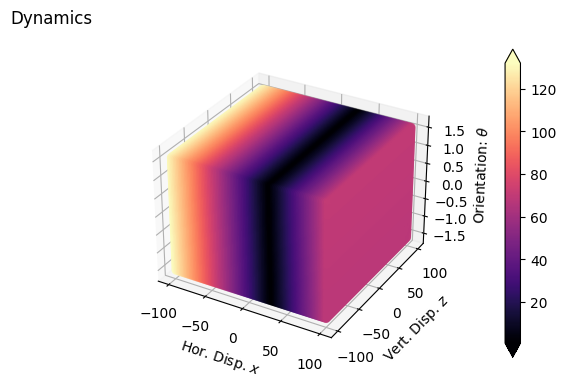

In [24]:
# plot solution space in space time 
fig = plt.figure(figsize=(16,4), )
ax = fig.add_subplot(111, projection='3d')

# Plot a few snapshots.
color = iter(plt.cm.viridis(np.linspace(.25, 1, 5)))

cdata = ax.scatter(X_all, Z_all, Theta_all, c=values, cmap="magma") #, shading="nearest", 
plt.colorbar(cdata, ax=ax, extend="both")
ax.set_xlabel(r"Hor. Disp. $x$")
ax.set_ylabel(r"Vert. Disp. $z$")
ax.set_zlabel(r"Orientation: $\theta$")

fig.suptitle("Dynamics")
plt.show()